# CO2 Emissions of Vehicles — EDA and Interpretable Regression Model

**Business context:** The Global Automotive Council wants to understand what drives vehicle CO2
emissions so it can guide emission-reduction policy and vehicle design decisions. This notebook
loads and cleans the data, explores it, engineers and selects features, and builds an interpretable
regression model whose coefficients directly answer which vehicle attributes influence emissions.

# 1. Setup — Imports and Data Load

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import skew
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
RANDOM_STATE = 42

df = pd.read_csv("CO2_Emissions.csv")
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head()

Loaded 7,385 rows and 12 columns.


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


# 2. Data Inspection and Cleaning

In [2]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
df.info()

Shape: 7,385 rows x 12 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               738

In [3]:
display(df[numerical_cols].describe().T)
df.nunique().sort_values().to_frame("unique_values")

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),7385.0,3.160068,1.354170,0.9,2.0,3.0,3.7,8.4
Cylinders,7385.0,5.615030,1.828307,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),7385.0,12.556534,3.500274,4.2,10.1,12.1,14.6,30.6
Fuel Consumption Hwy (L/100 km),7385.0,9.041706,2.224456,4.0,7.5,8.7,10.2,20.6
Fuel Consumption Comb (L/100 km),7385.0,10.975071,2.892506,4.1,8.9,10.6,12.6,26.1
Fuel Consumption Comb (mpg),7385.0,27.481652,7.231879,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),7385.0,250.584699,58.512679,96.0,208.0,246.0,288.0,522.0


,unique_values
Fuel Type,5
Cylinders,8
Vehicle Class,16
Transmission,27
Make,42
Engine Size(L),51
Fuel Consumption Comb (mpg),54
Fuel Consumption Hwy (L/100 km),143
Fuel Consumption Comb (L/100 km),181
Fuel Consumption City (L/100 km),211


In [4]:
print("Missing values:", df.isnull().sum().sum())
print(f"Exact duplicate rows: {df.duplicated().sum():,} ({df.duplicated().mean():.1%} of the data)")

print("\nCategorical category samples (checking for case/spelling inconsistencies):")
for col in categorical_cols:
    print(f"  {col:15s} -> {df[col].nunique():5d} unique | e.g. {list(df[col].unique()[:4])}")

print("\nWhitespace issues per text column:")
for col in categorical_cols:
    n_ws = (df[col].astype(str) != df[col].astype(str).str.strip()).sum()
    print(f"  {col:15s} -> {n_ws} value(s) with leading/trailing whitespace")

target_col = "CO2 Emissions(g/km)"
print(f"\nTarget ({target_col}) range: {df[target_col].min()}-{df[target_col].max()}, "
      f"zero/negative values: {(df[target_col] <= 0).sum()}")

Missing values: 0
Exact duplicate rows: 1,103 (14.9% of the data)

Categorical category samples (checking for case/spelling inconsistencies):
  Make            ->    42 unique | e.g. ['ACURA', 'ALFA ROMEO', 'ASTON MARTIN', 'AUDI']
  Model           ->  2053 unique | e.g. ['ILX', 'ILX HYBRID', 'MDX 4WD', 'RDX AWD']
  Vehicle Class   ->    16 unique | e.g. ['COMPACT', 'SUV - SMALL', 'MID-SIZE', 'TWO-SEATER']
  Transmission    ->    27 unique | e.g. ['AS5', 'M6', 'AV7', 'AS6']
  Fuel Type       ->     5 unique | e.g. ['Z', 'D', 'X', 'E']

Whitespace issues per text column:
  Make            -> 0 value(s) with leading/trailing whitespace
  Model           -> 5 value(s) with leading/trailing whitespace
  Vehicle Class   -> 0 value(s) with leading/trailing whitespace
  Transmission    -> 0 value(s) with leading/trailing whitespace
  Fuel Type       -> 0 value(s) with leading/trailing whitespace

Target (CO2 Emissions(g/km)) range: 96-522, zero/negative values: 0


**Findings:** no missing values and no inconsistent category spellings (`Make`, `Vehicle Class`,
`Transmission`, `Fuel Type` are all clean, consistently-cased codes). Two real issues surfaced:
**~1,100+ exact duplicate rows (~15% of the data)** and a handful of `Model` values with stray
whitespace. The target is fully populated and physically plausible (96-522 g/km, no zero/negative
values). We fix exactly these two issues below — nothing else needs correction.

In [5]:
df_clean = df.copy()
for col in categorical_cols:
    df_clean[col] = df_clean[col].str.strip()

before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Whitespace stripped on all text columns.")
print(f"Duplicate rows removed: {before - len(df_clean):,} ({(before - len(df_clean)) / before:.1%})")
print(f"Final cleaned dataset: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")

Whitespace stripped on all text columns.
Duplicate rows removed: 1,104 (14.9%)
Final cleaned dataset: 6,281 rows x 12 columns


# 3. Exploratory Data Analysis

## 3.1 Univariate Analysis — Numerical Features

Histogram+KDE (distribution shape) and boxplot (outliers) for each numerical predictor, skewness
annotated directly on each histogram.

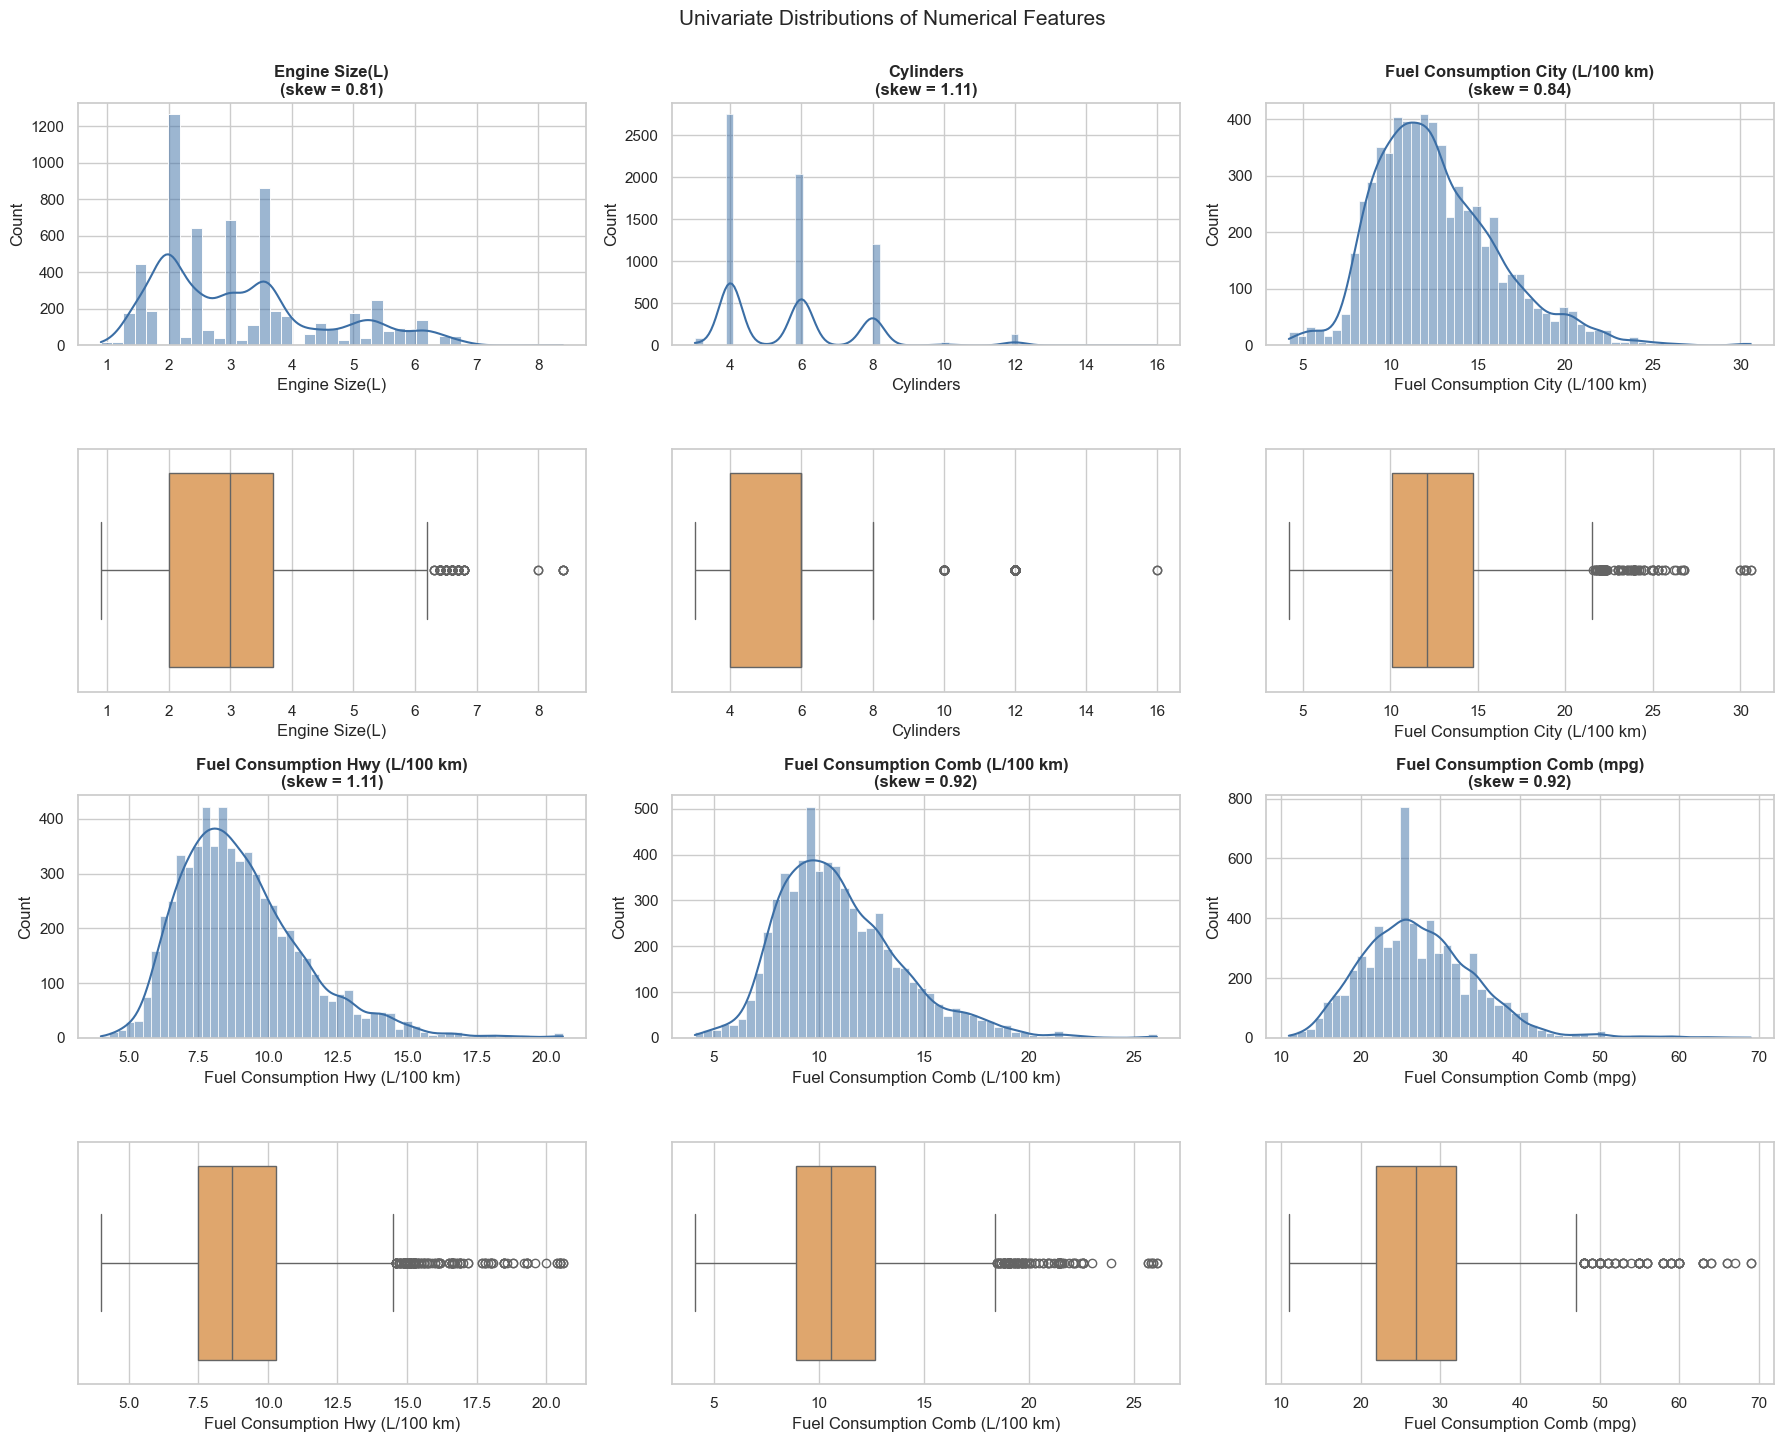

In [6]:
numerical_features = ["Engine Size(L)", "Cylinders", "Fuel Consumption City (L/100 km)",
                       "Fuel Consumption Hwy (L/100 km)", "Fuel Consumption Comb (L/100 km)",
                       "Fuel Consumption Comb (mpg)"]
categorical_features = ["Make", "Vehicle Class", "Transmission", "Fuel Type"]


def plot_distributions(data, columns, ncols=3):
    nrows = -(-len(columns) // ncols)
    fig, axes = plt.subplots(nrows * 2, ncols, figsize=(6 * ncols, 3.6 * nrows * 2))
    axes = axes.reshape(nrows * 2, ncols)
    for i, col in enumerate(columns):
        r, c = divmod(i, ncols)
        sns.histplot(data[col], kde=True, ax=axes[2 * r, c], color="#3b6ea5", edgecolor="white")
        axes[2 * r, c].set_title(f"{col}\n(skew = {skew(data[col]):.2f})")
        sns.boxplot(x=data[col], ax=axes[2 * r + 1, c], color="#f2a65a")
    for j in range(len(columns), nrows * ncols):
        r, c = divmod(j, ncols)
        axes[2 * r, c].axis("off")
        axes[2 * r + 1, c].axis("off")
    fig.suptitle("Univariate Distributions of Numerical Features", fontsize=15, y=1.0)
    fig.tight_layout()
    plt.show()


plot_distributions(df_clean, numerical_features)

**Interpretation:** every numerical predictor is moderately right-skewed (0.8-1.1), with a compact
interquartile range and a cluster of high-end outliers (large/high-consumption vehicles) — no
low-end outliers. This mild, consistent skew does not demand a transformation for modeling.

## 3.2 Univariate Analysis — Categorical Features

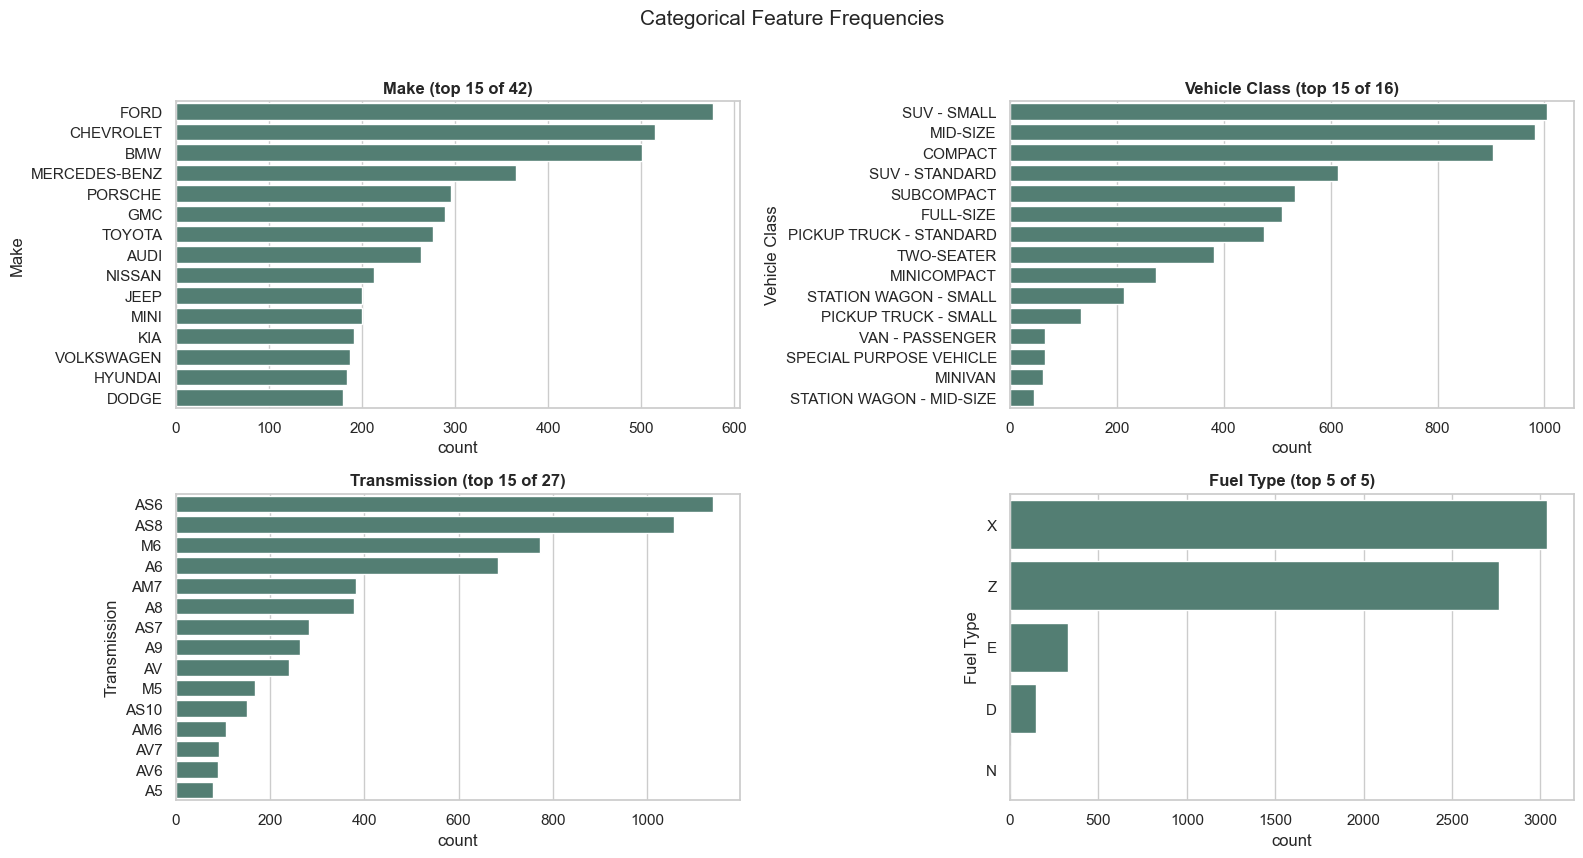

,dominant_category,share_of_data
Make,FORD,9.2%
Vehicle Class,SUV - SMALL,16.0%
Transmission,AS6,18.1%
Fuel Type,X,48.4%


In [7]:
def plot_categorical_counts(data, columns, ncols=2, top_n=15):
    nrows = -(-len(columns) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 4.2 * nrows))
    axes = axes.flatten()
    for ax, col in zip(axes, columns):
        top_categories = data[col].value_counts().head(top_n).index
        sns.countplot(data=data[data[col].isin(top_categories)], y=col,
                      order=top_categories, ax=ax, color="#4c8577")
        ax.set_title(f"{col} (top {min(top_n, data[col].nunique())} of {data[col].nunique()})")
    for ax in axes[len(columns):]:
        ax.axis("off")
    fig.suptitle("Categorical Feature Frequencies", fontsize=15, y=1.02)
    fig.tight_layout()
    plt.show()


plot_categorical_counts(df_clean, categorical_features)

dominant = pd.DataFrame({
    col: [df_clean[col].value_counts().idxmax(),
          f"{df_clean[col].value_counts(normalize=True).max():.1%}"]
    for col in categorical_features
}, index=["dominant_category", "share_of_data"]).T
dominant

**Interpretation:** `Fuel Type` is dominated by regular/premium gasoline (`X`/`Z`); `Vehicle Class`
by mainstream passenger segments; `Transmission` by automatic variants. `Make` has 42 categories
including several low-volume exotic brands — worth remembering when interpreting brand-level effects
later, since small samples produce statistically fragile estimates.

## 3.3 Target Variable — CO2 Emissions(g/km)

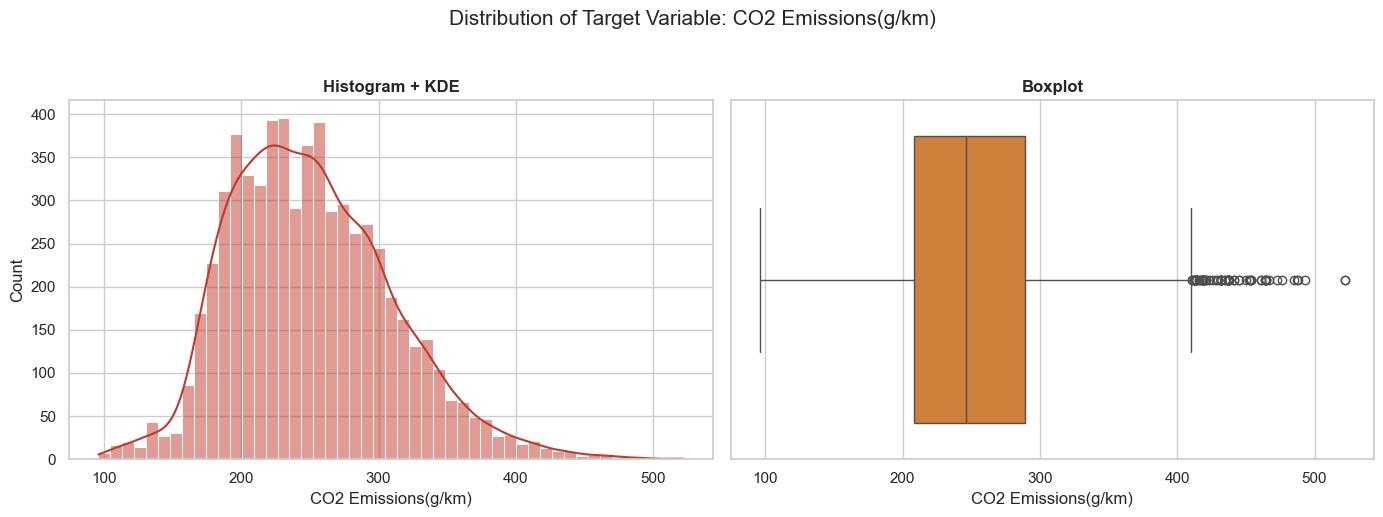

Skewness: 0.556


count    6281.000000
mean      251.164942
std        59.292408
min        96.000000
25%       208.000000
50%       246.000000
75%       289.000000
max       522.000000
Name: CO2 Emissions(g/km), dtype: float64

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean[target_col], kde=True, ax=axes[0], color="#c0392b", edgecolor="white")
axes[0].set_title("Histogram + KDE")
sns.boxplot(x=df_clean[target_col], ax=axes[1], color="#e67e22")
axes[1].set_title("Boxplot")
fig.suptitle("Distribution of Target Variable: CO2 Emissions(g/km)", fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

print(f"Skewness: {skew(df_clean[target_col]):.3f}")
df_clean[target_col].describe()

**Interpretation:** emissions range 96-522 g/km, mean ~251 g/km, skew ~0.56 — the mildest of all
numerical columns, and close enough to symmetric that no target transformation is needed.

## 3.4 Bivariate Analysis — Numerical Features vs. Target

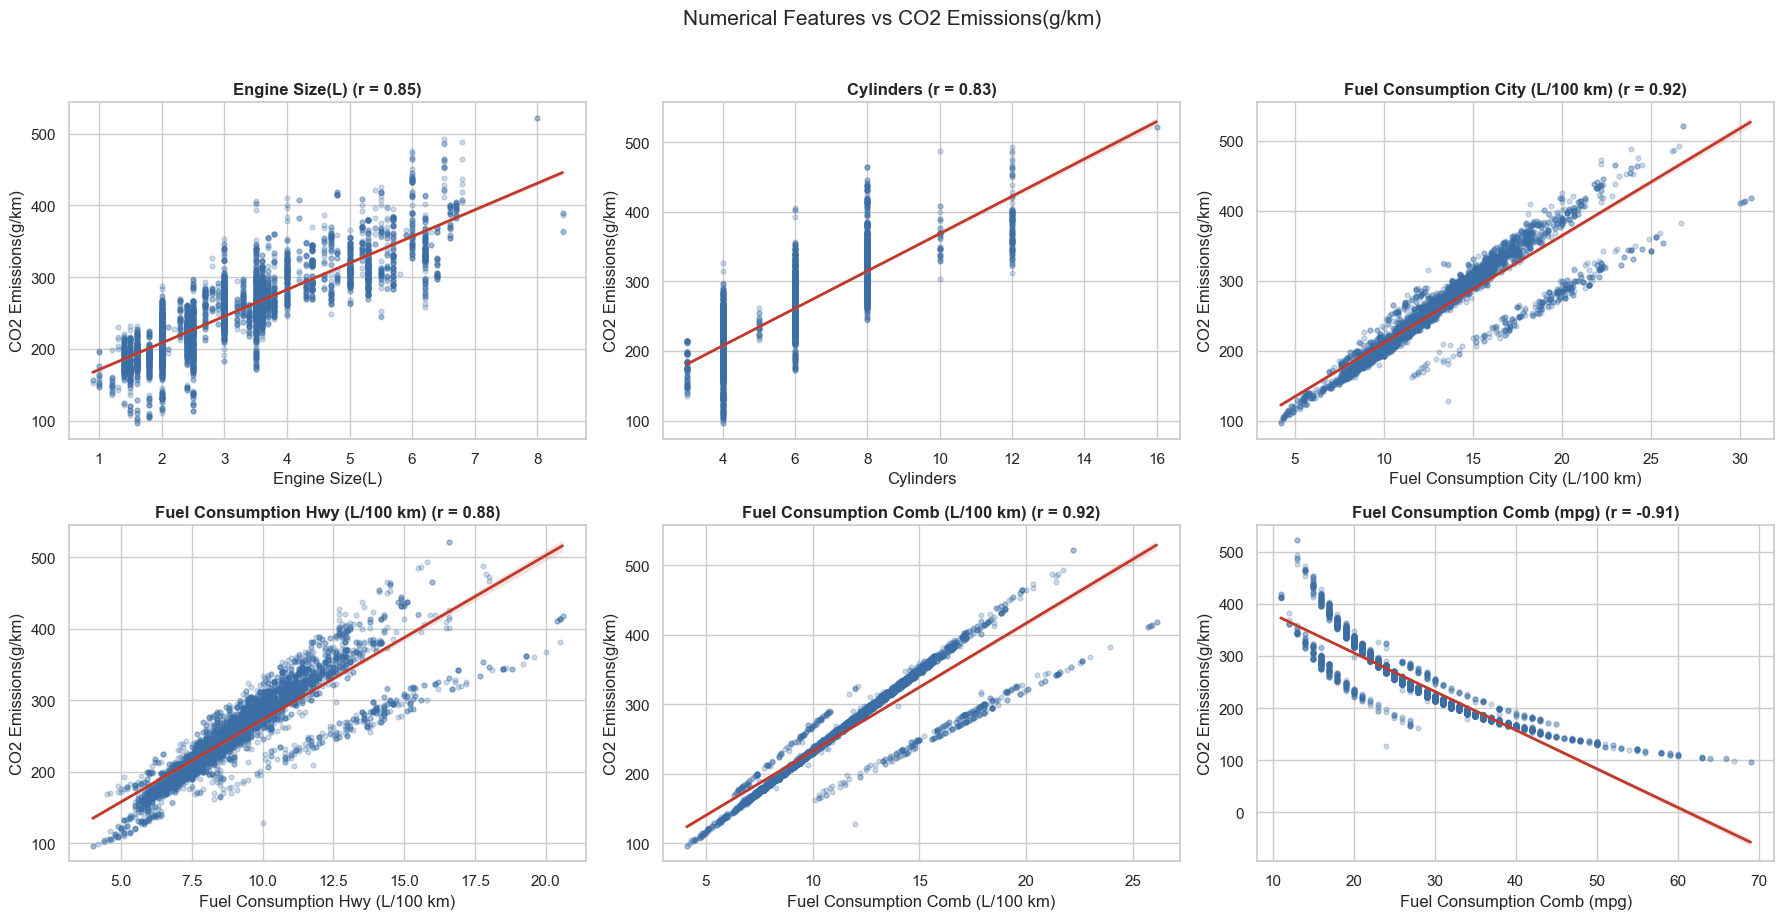

In [9]:
def plot_scatter_with_regression(data, columns, target, ncols=3):
    nrows = -(-len(columns) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = axes.flatten()
    for ax, col in zip(axes, columns):
        sns.regplot(data=data, x=col, y=target, ax=ax,
                     scatter_kws={"alpha": 0.25, "s": 12, "color": "#3b6ea5"},
                     line_kws={"color": "#c0392b", "linewidth": 2})
        ax.set_title(f"{col} (r = {data[col].corr(data[target]):.2f})")
    for ax in axes[len(columns):]:
        ax.axis("off")
    fig.suptitle(f"Numerical Features vs {target}", fontsize=15, y=1.02)
    fig.tight_layout()
    plt.show()


plot_scatter_with_regression(df_clean, numerical_features, target_col)

**Interpretation:** all six numerical features are strongly related to CO2 emissions (|r| = 0.83-0.92)
— fuel-consumption measures show the tightest, most linear fit (fuel burned is almost mechanically
proportional to CO2 produced); `mpg`'s relationship is curved since it is a reciprocal-scaled
measure; `Engine Size`/`Cylinders` are strong but noisier, since they affect emissions only
indirectly, through fuel consumption.

## 3.5 Bivariate Analysis — Categorical Features vs. Target

Boxplots ordered by median CO2 (a violin-plot view would show the same distributional story with no
added decision-relevant information, so we keep only the boxplot for conciseness), plus each
category's mean CO2 and sample size.

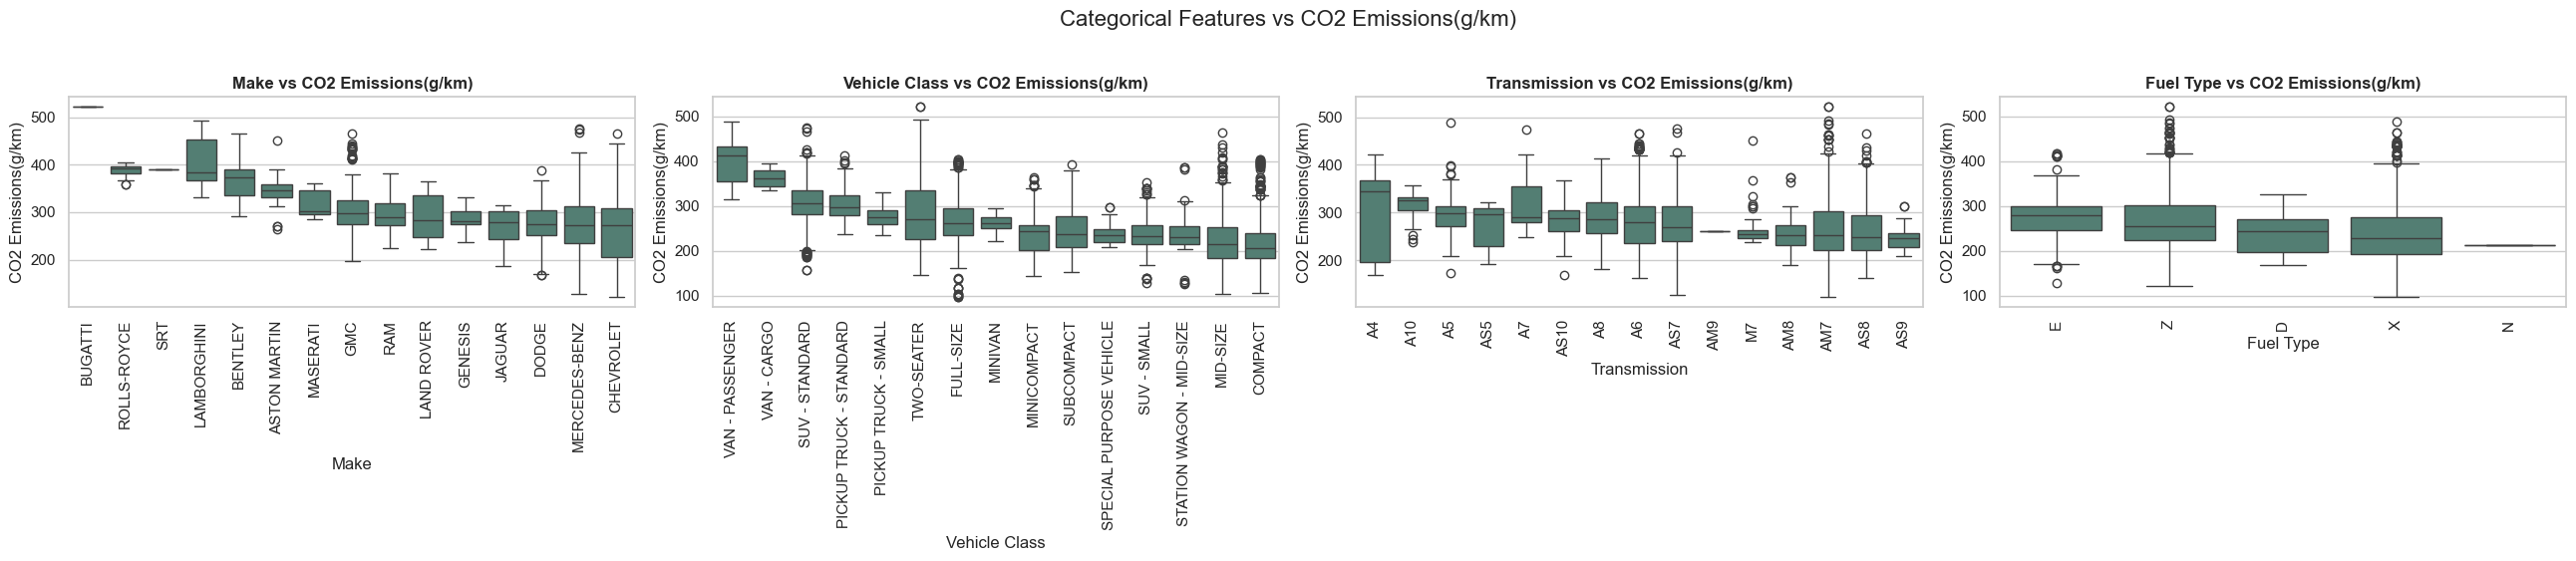

In [10]:
def plot_categorical_vs_target(data, columns, target, top_n=15):
    fig, axes = plt.subplots(1, len(columns), figsize=(6.5 * len(columns), 5.5))
    for ax, col in zip(axes, columns):
        order = data.groupby(col, observed=True)[target].median().sort_values(ascending=False).index[:top_n]
        sns.boxplot(data=data[data[col].isin(order)], x=col, y=target, order=order, ax=ax, color="#4c8577")
        ax.set_title(f"{col} vs {target}")
        ax.tick_params(axis="x", rotation=90)
    fig.suptitle(f"Categorical Features vs {target}", fontsize=16, y=1.02)
    fig.tight_layout()
    plt.show()


plot_categorical_vs_target(df_clean, categorical_features, target_col)

In [11]:
for col in categorical_features:
    top3 = (df_clean.groupby(col, observed=True)[target_col].agg(["mean", "count"])
            .sort_values("mean", ascending=False).round(1).head(3))
    print(f"{col} — highest-CO2 categories:")
    print(top3.to_string(), "\n")

Make — highest-CO2 categories:
              mean  count
Make                     
BUGATTI      522.0      2
LAMBORGHINI  402.3     37
SRT          389.0      2 

Vehicle Class — highest-CO2 categories:
                  mean  count
Vehicle Class                
VAN - PASSENGER  397.2     66
VAN - CARGO      361.5     22
SUV - STANDARD   306.7    613 

Transmission — highest-CO2 categories:
               mean  count
Transmission              
A7            314.3     44
A10           314.0     28
A5            299.4     78 

Fuel Type — highest-CO2 categories:
            mean  count
Fuel Type              
E          276.0    330
Z          265.7   2765
X          236.0   3038 



**Interpretation:** `Vehicle Class` shows the clearest separation (vans/trucks highest, station
wagons/compacts lowest). `Fuel Type`'s apparent ranking (ethanol/premium highest) is confounded with
engine size, not a pure fuel-chemistry effect. `Make`'s highest categories are exotic/performance
brands, several with very few vehicles — read as anecdotal, not representative, until a controlled
model (Section 6) confirms whether the effect survives holding engine size constant.

## 3.6 Correlation and Multicollinearity

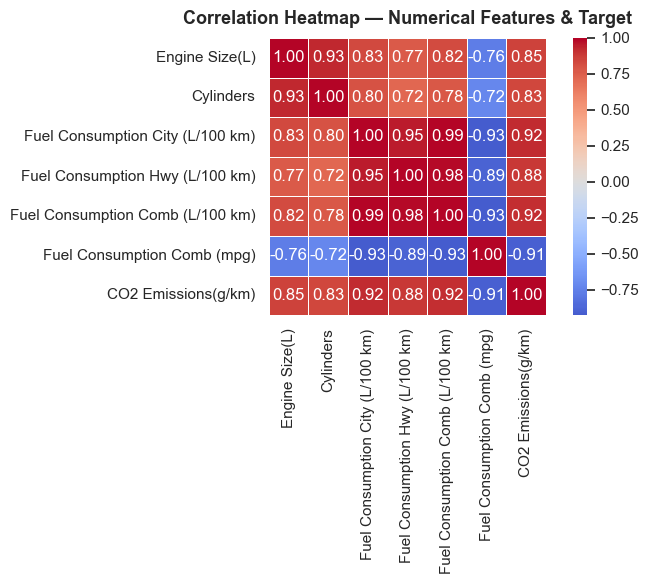

In [12]:
corr_matrix = df_clean[numerical_features + [target_col]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, square=True, ax=ax)
ax.set_title("Correlation Heatmap — Numerical Features & Target", fontsize=13, pad=10)
fig.tight_layout()
plt.show()

In [13]:
def compute_vif(data, columns):
    X = data[columns]
    return pd.DataFrame({
        "feature": columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    }).sort_values("VIF", ascending=False).reset_index(drop=True)


compute_vif(df_clean, numerical_features)

,feature,VIF
0,Fuel Consumption Comb (L/100 km),75433.558859
1,Fuel Consumption City (L/100 km),30256.939328
2,Fuel Consumption Hwy (L/100 km),10499.959756
3,Cylinders,78.939772
4,Engine Size(L),55.146731
5,Fuel Consumption Comb (mpg),6.884807


**Interpretation:** `City`/`Hwy`/`Comb (L/100 km)` correlate at r > 0.85 and show **extreme VIF (in
the thousands)** because `Comb` is *defined* as `0.55*City + 0.45*Hwy` — a mathematical identity, not
a coincidence. `Comb (mpg)` is a reciprocal rescaling of the same quantity. `Engine Size`/`Cylinders`
correlate at r~0.93 (VIF ~55-80) since larger engines mechanically need more cylinders. No numerical
feature here is "safely independent" — this is exactly the redundancy Feature Engineering (Section
4) resolves.

## 3.7 Outlier Analysis

,feature,n_outliers,pct_outliers
0,Cylinders,177,2.82
1,Fuel Consumption Hwy (L/100 km),150,2.39
2,Engine Size(L),121,1.93
3,Fuel Consumption City (L/100 km),116,1.85
4,Fuel Consumption Comb (L/100 km),115,1.83
5,Fuel Consumption Comb (mpg),95,1.51
6,CO2 Emissions(g/km),74,1.18


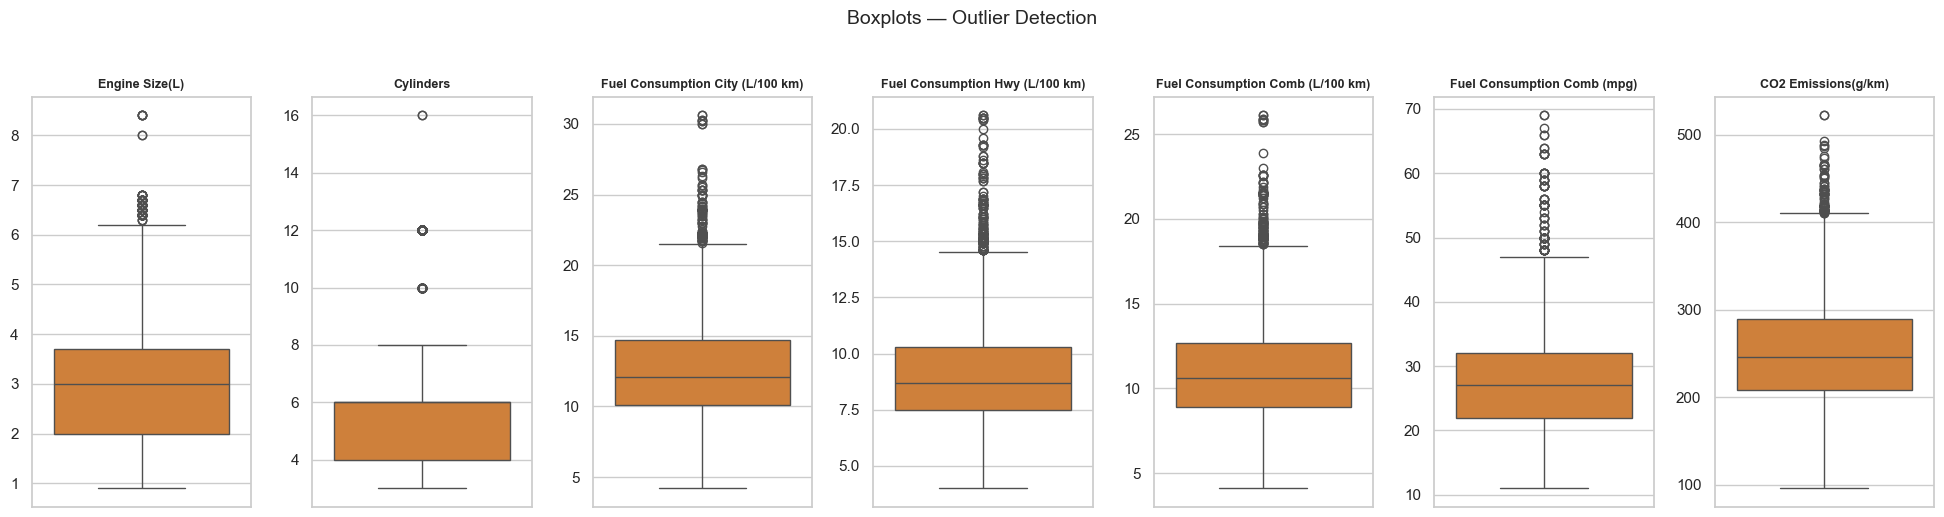

In [14]:
def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append({"feature": col, "n_outliers": n, "pct_outliers": round(100 * n / len(data), 2)})
    return pd.DataFrame(rows).sort_values("n_outliers", ascending=False).reset_index(drop=True)


all_num_cols = numerical_features + [target_col]
display(iqr_outlier_summary(df_clean, all_num_cols))

fig, axes = plt.subplots(1, len(all_num_cols), figsize=(2.8 * len(all_num_cols), 5))
for ax, col in zip(axes, all_num_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color="#e67e22")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
fig.suptitle("Boxplots — Outlier Detection", fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

**Interpretation:** 1-3% of records per column are IQR-flagged outliers, all on the high end (large
trucks/SUVs, high-performance/exotic cars). These are genuine, policy-relevant vehicles, not data
errors — removing them would bias the dataset against exactly the vehicles emissions policy needs to
address. We retain all outliers through modeling; a regularized model (Section 6) handles them
without needing to discard data.

# 4. Feature Engineering and Selection

Section 3.6 showed severe multicollinearity among the numerical features. Here we resolve it —
deciding, for each redundant group, which single representative to keep, using correlation with the
target, VIF, and domain knowledge (not just whichever has the statistically "cleanest" VIF).

## 4.1 Transmission — Family vs. Gear Count

`Transmission` packs a mechanism family (Automatic/Automated Manual/Automatic Select
Shift/Continuously Variable/Manual) and a gear-count suffix into one code. We test whether gear
count adds information beyond family, rather than assuming either way.

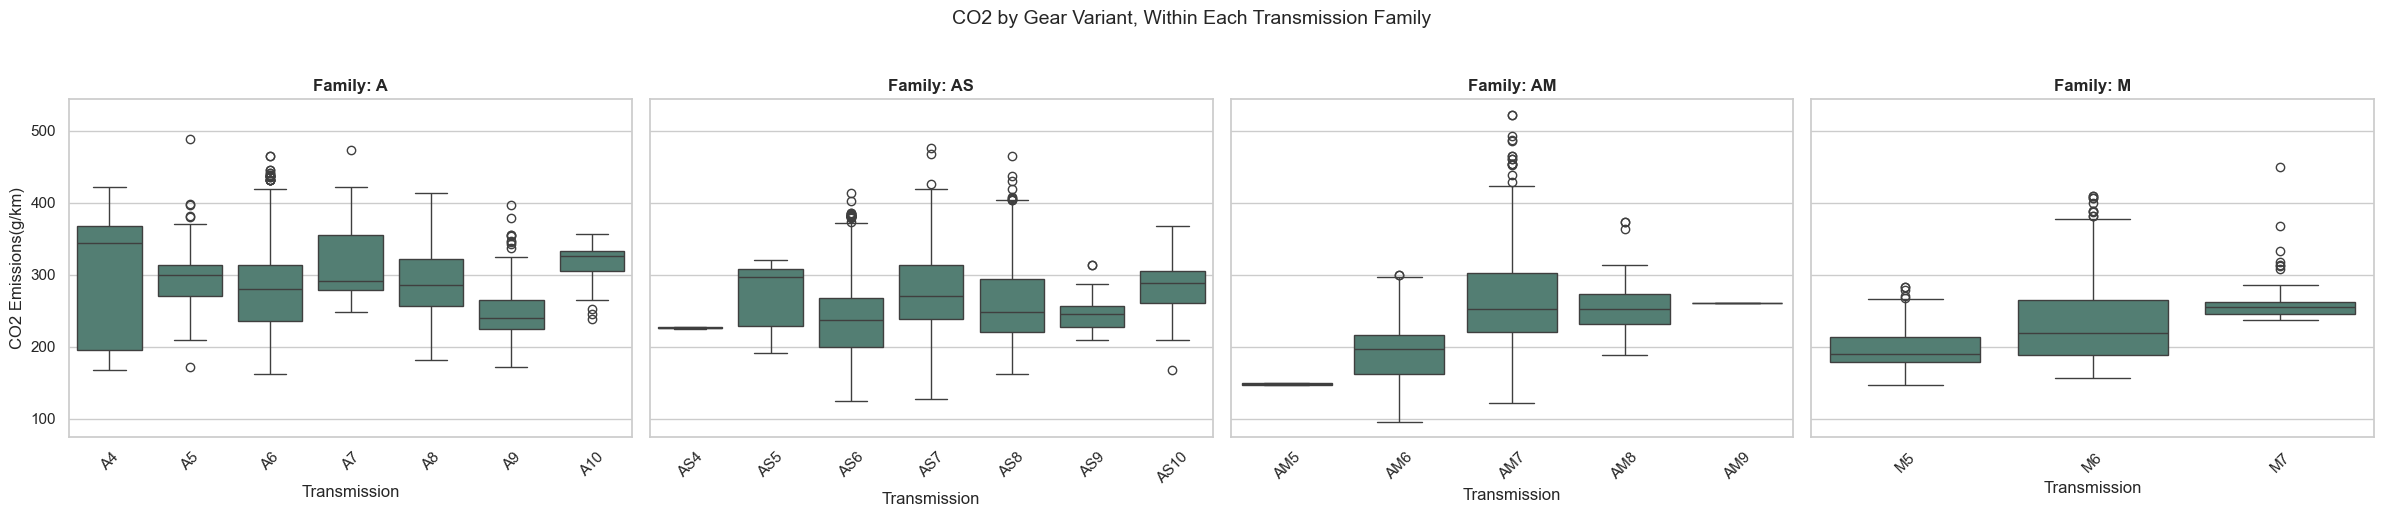

Correlation between gear count and CO2, computed WITHIN each family:
  A  : r = -0.146  (n=1536)
  AS : r = +0.203  (n=2722)
  AM : r = +0.366  (n=540)


In [15]:
transmission_family = df_clean["Transmission"].str.extract(r"([A-Za-z]+)")[0]
transmission_gears = df_clean["Transmission"].str.extract(r"(\d+)")[0].astype(float)

fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharey=True)
for ax, fam in zip(axes, ["A", "AS", "AM", "M"]):
    subset = df_clean.loc[transmission_family == fam, ["Transmission", target_col]]
    order = sorted(subset["Transmission"].unique(), key=lambda x: (len(x), x))
    sns.boxplot(data=subset, x="Transmission", y=target_col, order=order, ax=ax, color="#4c8577")
    ax.set_title(f"Family: {fam}")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("CO2 by Gear Variant, Within Each Transmission Family", fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

print("Correlation between gear count and CO2, computed WITHIN each family:")
for fam in ["A", "AS", "AM"]:
    mask = transmission_family == fam
    r = transmission_gears[mask].corr(df_clean.loc[mask, target_col])
    print(f"  {fam:3s}: r = {r:+.3f}  (n={mask.sum()})")

**Conclusion:** family-level averages differ substantially (~184 g/km for CVT up to ~278 g/km for
conventional Automatic), but gear count's correlation with CO2 **flips sign across families**
(-0.15 in `A`, +0.20 in `AS`, +0.37 in `AM`) — not a stable, generalizable effect — and is undefined
for CVTs entirely. We extract **`Transmission_Family`** only, discarding gear count.

In [16]:
df_clean["Transmission_Family"] = transmission_family.astype("category")
df_clean = df_clean.drop(columns=["Transmission"])

## 4.2 Engine Size vs. Cylinders vs. an Engineered Ratio

`Engine Size(L)` and `Cylinders` are highly correlated (r~0.93). Rather than blindly dropping one, we
also test `Engine_Size_Per_Cylinder` (displacement per cylinder) as a candidate.

In [17]:
df_clean["Engine_Size_Per_Cylinder"] = df_clean["Engine Size(L)"] / df_clean["Cylinders"]
engine_candidates = ["Engine Size(L)", "Cylinders", "Engine_Size_Per_Cylinder"]

print("Correlation with target:")
print(df_clean[engine_candidates + [target_col]].corr()[target_col].drop(target_col)
      .sort_values(key=abs, ascending=False))
print()
print("VIF, all three together:")
compute_vif(df_clean, engine_candidates)

Correlation with target:
Engine Size(L)              0.854787
Cylinders                   0.834670
Engine_Size_Per_Cylinder    0.588900
Name: CO2 Emissions(g/km), dtype: float64

VIF, all three together:


,feature,VIF
0,Cylinders,46.178029
1,Engine Size(L),39.852582
2,Engine_Size_Per_Cylinder,13.259757


**Conclusion: keep `Engine Size(L)` only.** It has the highest standalone target correlation
(r~0.855, vs. 0.835 for `Cylinders` and just 0.589 for the ratio) and is the more standard,
policy-interpretable spec (engine downsizing is a real regulatory lever); dropping `Cylinders` and
the ratio removes the most severe multicollinearity (VIF ~40-80) at negligible cost, since the
ratio's own predictive power is materially weaker and remains collinear with engine size regardless
(VIF ~11 even paired alone). `Engine_Size_Per_Cylinder` stays in `df_clean` for reference but is not
carried into modeling.

## 4.3 Fuel Consumption — Four Measures of One Signal

`City`, `Hwy`, `Comb (L/100 km)`, and `Comb (mpg)` all measure fuel consumption. All four correlate
with the target almost equally (|r| 0.88-0.92) — correlation alone can't choose between them, so we
lean on the mathematical relationship instead.

In [18]:
fuel_candidates = ["Fuel Consumption City (L/100 km)", "Fuel Consumption Hwy (L/100 km)",
                    "Fuel Consumption Comb (L/100 km)", "Fuel Consumption Comb (mpg)"]
print("Correlation among fuel measures:")
display(df_clean[fuel_candidates].corr().round(3))
print("VIF, all four together:")
compute_vif(df_clean, fuel_candidates)

Correlation among fuel measures:


,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
Fuel Consumption City (L/100 km),1.000,0.951,0.994,-0.928
Fuel Consumption Hwy (L/100 km),0.951,1.000,0.979,-0.892
Fuel Consumption Comb (L/100 km),0.994,0.979,1.000,-0.926
Fuel Consumption Comb (mpg),-0.928,-0.892,-0.926,1.000


VIF, all four together:


,feature,VIF
0,Fuel Consumption Comb (L/100 km),75425.730164
1,Fuel Consumption City (L/100 km),30194.370795
2,Fuel Consumption Hwy (L/100 km),10487.682161
3,Fuel Consumption Comb (mpg),4.999993


**Conclusion: keep `Fuel Consumption Comb (L/100 km)` only.** It correlates at r=0.994 with `City`
and r=0.951 with `Hwy` because it is *defined* as their weighted average (0.55*City + 0.45*Hwy) — it
already captures nearly all of both in one number representing real-world blended driving, which is
also the quantity regulators and consumers actually care about. `Comb (mpg)` is dropped as a pure
reciprocal rescaling of the same figure (VIF in the tens of thousands otherwise).

## 4.4 Final Feature Selection

| Removed feature | Why |
|---|---|
| `Cylinders` | Redundant with `Engine Size(L)` (r=0.93); Engine Size has higher target correlation and is more interpretable. |
| `Engine_Size_Per_Cylinder` | Weaker target correlation (r=0.59) than Engine Size alone; still collinear with it (VIF~11). |
| `Fuel Consumption City/Hwy (L/100 km)` | r=0.99/0.95 with `Comb` — already captured by it. |
| `Fuel Consumption Comb (mpg)` | Reciprocal rescaling of `Comb (L/100 km)` — no new information. |
| `Transmission` (raw code) | Gear count showed no consistent within-family relationship with CO2; replaced by `Transmission_Family`. |

In [19]:
final_numerical_features = ["Engine Size(L)", "Fuel Consumption Comb (L/100 km)"]
final_categorical_features = ["Make", "Model", "Vehicle Class", "Transmission_Family", "Fuel Type"]
final_features = final_numerical_features + final_categorical_features

print("Final features:", final_features)
print("Residual VIF, Engine Size(L) vs Fuel Consumption Comb:")
compute_vif(df_clean, final_numerical_features)

Final features: ['Engine Size(L)', 'Fuel Consumption Comb (L/100 km)', 'Make', 'Model', 'Vehicle Class', 'Transmission_Family', 'Fuel Type']
Residual VIF, Engine Size(L) vs Fuel Consumption Comb:


,feature,VIF
0,Engine Size(L),17.440309
1,Fuel Consumption Comb (L/100 km),17.440309


**Note:** even after removing every mathematically-redundant column, `Engine Size(L)` and
`Fuel Consumption Comb (L/100 km)` still show VIF~17 between them, because larger engines
mechanically burn more fuel (r~0.82) — a genuine physical relationship, not an artifact, that cannot
be engineered away without discarding real information. This is resolved by model choice
(Section 6), not further feature removal.

In [20]:
df_engineered = df_clean[final_features + [target_col]].copy()
print(f"Engineered dataset shape: {df_engineered.shape}")
df_engineered.head()

Engineered dataset shape: (6281, 8)


,Engine Size(L),Fuel Consumption Comb (L/100 km),Make,Model,Vehicle Class,Transmission_Family,Fuel Type,CO2 Emissions(g/km)
0,2.0,8.5,ACURA,ILX,COMPACT,AS,Z,196
1,2.4,9.6,ACURA,ILX,COMPACT,M,Z,221
2,1.5,5.9,ACURA,ILX HYBRID,COMPACT,AV,Z,136
3,3.5,11.1,ACURA,MDX 4WD,SUV - SMALL,AS,Z,255
4,3.5,10.6,ACURA,RDX AWD,SUV - SMALL,AS,Z,244


# 5. Train-Test Split

We split before fitting any encoder, so every preprocessing step can be fit on training data only.

In [21]:
X = df_engineered[final_features].copy()
y = df_engineered[target_col].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")

X_train: (5024, 7)   X_test: (1257, 7)


## 5.1 Why `Make`/`Model` Need Care When Encoding

`Make` (42 categories) and `Model` (2,048 categories) are too high-cardinality for one-hot encoding
without exploding the feature space. A natural alternative is **target encoding** (replace each
category with its training-set mean CO2) — but this has a real failure mode worth demonstrating
before deciding the final approach: with `Model` spread across ~6,300 rows, most `Model` categories
have only 1-2 training examples, so their target-encoded value is nearly equal to that row's own
target — a leakage-like effect that shows up as extreme multicollinearity.

In [22]:
train_only_makes = y_train.groupby(X_train["Make"].astype(object)).mean()
train_only_models = y_train.groupby(X_train["Model"].astype(object)).mean()
global_mean = y_train.mean()

make_enc = X_train["Make"].astype(object).map(train_only_makes).fillna(global_mean)
model_enc = X_train["Model"].astype(object).map(train_only_models).fillna(global_mean)

demo_vif = compute_vif(
    pd.DataFrame({
        "Make_target_enc": make_enc, "Model_target_enc": model_enc,
        "Engine Size(L)": X_train["Engine Size(L)"].values,
        "Fuel Consumption Comb": X_train["Fuel Consumption Comb (L/100 km)"].values,
    }),
    ["Make_target_enc", "Model_target_enc", "Engine Size(L)", "Fuel Consumption Comb"],
)
demo_vif

,feature,VIF
0,Model_target_enc,139.454590
1,Fuel Consumption Comb,93.221836
2,Make_target_enc,35.564725
3,Engine Size(L),19.577534


**Finding:** `Model_target_enc` shows extreme VIF, dragging `Fuel Consumption Comb` up with it —
because ~40% of `Model` categories are single-row in training, target encoding effectively
memorizes the target for those rows. This is why **the final model (Section 6) drops `Model`
entirely and one-hot encodes `Make`** (only 42, manageable categories) instead of target-encoding
either — trading a small amount of dimensionality for coefficients that are both leak-free and
individually interpretable.

# 6. Interpretable Regression Model

The business questions prioritize **understanding which vehicle design/policy levers drive CO2
emissions** over squeezing out maximum predictive accuracy. This motivates a deliberately narrower,
interpretable model rather than one using every available feature.

**Features:** `Engine Size(L)`, `Make`, `Vehicle Class`, `Transmission_Family`, `Fuel Type`.

**Deliberately excluded:**
- **`Fuel Consumption Comb (L/100 km)`** — CO2 output is chemically almost a fixed multiple of fuel
  burned, so fuel consumption sits *between* design attributes and emissions
  (Engine Size/Class -> Fuel Consumption -> CO2). Including it would let the model "explain"
  emissions via combustion chemistry rather than actionable design attributes, and would crowd out
  Engine Size's and Vehicle Class's coefficients (mediator-inclusion bias).
- **`Model`** — a near-identifier (2,048 categories) that is not a business-actionable lever and is
  largely redundant with Make + Engine Size + Vehicle Class + Fuel Type once those are known.

We reuse the same 80/20 split from Section 5.

In [23]:
model_b_features = ["Engine Size(L)", "Make", "Vehicle Class", "Transmission_Family", "Fuel Type"]
X_train_b = X_train[model_b_features].copy()
X_test_b = X_test[model_b_features].copy()

categorical_features_b = ["Make", "Vehicle Class", "Transmission_Family", "Fuel Type"]
preprocessor_b = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), ["Engine Size(L)"]),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
         categorical_features_b),
    ],
    remainder="drop", verbose_feature_names_out=False,
)
preprocessor_b.fit(X_train_b, y_train)

X_train_b_encoded = pd.DataFrame(preprocessor_b.transform(X_train_b),
                                  columns=preprocessor_b.get_feature_names_out(), index=X_train_b.index).astype(float)
X_test_b_encoded = pd.DataFrame(preprocessor_b.transform(X_test_b),
                                 columns=preprocessor_b.get_feature_names_out(), index=X_test_b.index).astype(float)

print(f"X_train_b_encoded: {X_train_b_encoded.shape}   X_test_b_encoded: {X_test_b_encoded.shape}")
print("Baseline categories dropped by one-hot encoding:",
      {c: sorted(X_train_b[c].unique())[0] for c in categorical_features_b})

X_train_b_encoded: (5024, 64)   X_test_b_encoded: (1257, 64)
Baseline categories dropped by one-hot encoding: {'Make': 'ACURA', 'Vehicle Class': 'COMPACT', 'Transmission_Family': 'A', 'Fuel Type': 'D'}


C:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


`Engine Size(L)` is standardized (Ridge penalizes coefficient magnitude, so it needs comparable scale
to the 0/1 dummies); the dummies themselves are left unscaled so each coefficient reads directly as
"g/km CO2 vs. the baseline category" shown above. `Make` is one-hot (not target-) encoded here — with
only 42 categories this is a manageable size, and it avoids the leakage shown in Section 5.1 while
giving an individually auditable coefficient per brand.

## 6.1 Train Ridge Regression (Cross-Validated Alpha)

Ridge is the right choice given the residual Engine-Size/Fuel-Consumption-shaped collinearity noted
in Section 4.4 (though Fuel Consumption itself isn't in this model, similar correlated-feature
patterns can arise among the retained ones, e.g. engine size vs. vehicle class): it shrinks correlated
coefficients together rather than letting OLS distribute weight between them erratically.

In [24]:
ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_model.fit(X_train_b_encoded, y_train)
print(f"Selected alpha: {ridge_model.alpha_:.4f}  (grid: 0.001 to 1000, interior optimum)")

Selected alpha: 0.1207  (grid: 0.001 to 1000, interior optimum)


## 6.2 Model Evaluation

Train  ->  R2 = 0.8727   RMSE =  21.09 g/km   MAE =  15.70 g/km
Test   ->  R2 = 0.8721   RMSE =  21.47 g/km   MAE =  16.25 g/km
Test MAE as % of average emissions: 6.4%


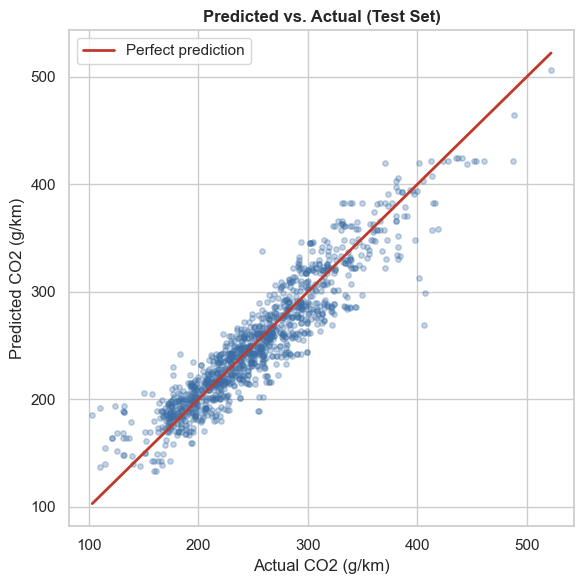

In [25]:
def regression_report(y_true, y_pred, label):
    r2, rmse, mae = (r2_score(y_true, y_pred), mean_squared_error(y_true, y_pred) ** 0.5,
                      mean_absolute_error(y_true, y_pred))
    print(f"{label:6s} ->  R2 = {r2:.4f}   RMSE = {rmse:6.2f} g/km   MAE = {mae:6.2f} g/km")
    return r2, rmse, mae


y_pred_train = ridge_model.predict(X_train_b_encoded)
y_pred_test = ridge_model.predict(X_test_b_encoded)
regression_report(y_train, y_pred_train, "Train")
test_r2, test_rmse, test_mae = regression_report(y_test, y_pred_test, "Test")
print(f"Test MAE as % of average emissions: {test_mae / y_test.mean() * 100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_test, alpha=0.3, s=15, color="#3b6ea5")
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, color="#c0392b", linewidth=2, label="Perfect prediction")
ax.set_xlabel("Actual CO2 (g/km)"); ax.set_ylabel("Predicted CO2 (g/km)")
ax.set_title("Predicted vs. Actual (Test Set)"); ax.legend()
fig.tight_layout()
plt.show()

**Interpretation:** using only Engine Size, Make, Vehicle Class, Transmission Family, and Fuel Type
— no fuel-consumption or model-identity information — the model explains **~87% of the variance**
in emissions (test R²~0.87), with a typical error of ~16 g/km (~6% of average emissions). Train and
test R² are nearly identical (0.873 vs 0.872), so the model generalizes well without overfitting.
The scatter clusters tightly around the reference line with no systematic curve, and no evidence of
a poorly-specified functional form; the modest scatter at the high-emission end is explained by the
specific outlier vehicles examined in Section 6.4.

## 6.3 Which Factors Matter Most? (Ridge Coefficients)

Every coefficient is the estimated change in CO2 (g/km) for that feature, holding all others
constant — `Engine Size(L)` per standard deviation, every categorical coefficient relative to its
dropped baseline category (shown above).

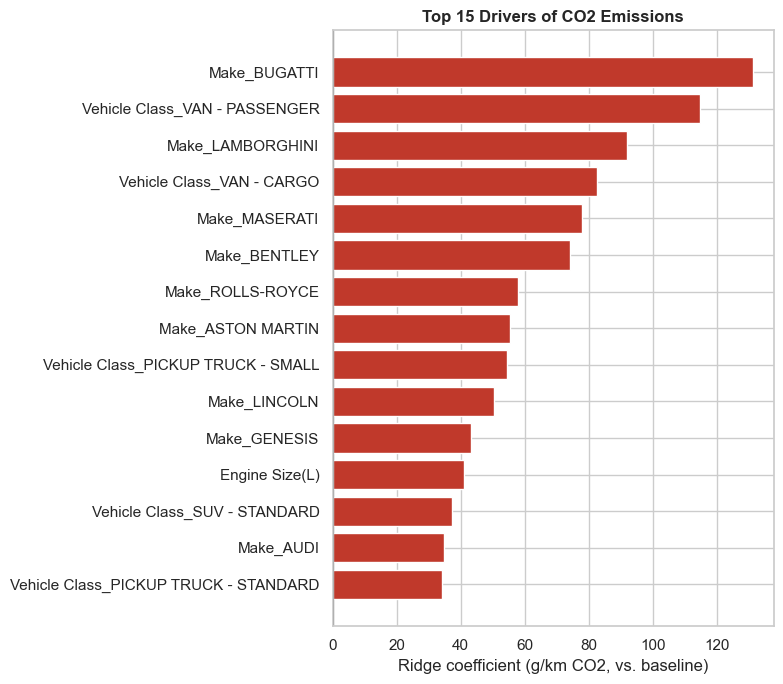

In [26]:
ridge_coefficients = pd.Series(ridge_model.coef_, index=X_train_b_encoded.columns,
                                name="coefficient").sort_values(key=abs, ascending=False)

top = ridge_coefficients.head(15).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index, top.values, color=["#c0392b" if v > 0 else "#3b6ea5" for v in top.values])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Ridge coefficient (g/km CO2, vs. baseline)")
ax.set_title("Top 15 Drivers of CO2 Emissions")
fig.tight_layout()
plt.show()

**Interpretation:**

- **`Engine Size(L)` (+41 g/km per SD)** is a strong, actionable driver that survives being
  estimated alongside Make and Vehicle Class — confirming EDA's raw correlation wasn't just a
  vehicle-class proxy.
- **Vehicle Class dominates the top of the list**: `VAN - PASSENGER` (+115) and `VAN - CARGO` (+83)
  add the most CO2 vs. the `COMPACT` baseline; pickups and standard SUVs are also elevated. Fleet
  composition (shifting mix away from vans/large SUVs/trucks) is the single largest lever visible
  here — larger than engine-size regulation alone.
- **Exotic/performance brands** (Bugatti, Lamborghini, Maserati, Bentley, Rolls-Royce, Aston Martin)
  show the largest brand premiums, even controlling for engine size and class — but treat the
  smallest ones cautiously: Bugatti's coefficient rests on a single training-set vehicle, while the
  broader luxury cluster (26-40 training examples each) is on firmer footing.
- These patterns broadly agree with EDA's raw group-means (Section 3.5), which is reassuring: the
  brand/class effects aren't merely an artifact of larger engines clustering in those groups, since
  Engine Size is already held constant here.

## 6.4 Residual Analysis — Which Vehicles Does the Model Get Wrong?

In [27]:
test_residuals = y_test - y_pred_test
residual_table = pd.DataFrame({
    "actual": y_test, "predicted": np.round(y_pred_test, 1), "abs_error": np.round(test_residuals.abs(), 1),
}).sort_values("abs_error", ascending=False)

worst = residual_table.head(8).join(df_clean.loc[residual_table.head(8).index,
                                                   ["Make", "Model", "Vehicle Class"]])
worst[["Make", "Model", "Vehicle Class", "actual", "predicted"]]

,Make,Model,Vehicle Class,actual,predicted
3467,FORD,GT,TWO-SEATER,406,269.2
50,AUDI,R8 SPYDER,TWO-SEATER,407,298.7
3815,MERCEDES-BENZ,G 550,SUV - STANDARD,401,312.5
3580,HYUNDAI,IONIQ,FULL-SIZE,103,185.9
3684,KIA,NIRO FE,STATION WAGON - SMALL,110,192.1
196,CHEVROLET,CORVETTE,TWO-SEATER,258,338.3
1047,VOLKSWAGEN,JETTA TURBO HYBRID,COMPACT,124,193.8
1894,SUBARU,WRX,COMPACT,255,189.0


**Interpretation:** two explainable failure patterns. **Hybrids are over-predicted** (Hyundai Ioniq,
Kia Niro/Optima Hybrid, VW Jetta Turbo Hybrid) — `Fuel Type` doesn't distinguish hybrid drivetrains,
so the model can't know these achieve unusually low emissions for their size/class: a missing
signal, not a modeling flaw. **Extreme performance cars are under-predicted** (Ford GT, Audi R8,
Corvette, Lamborghini Aventador) — their performance tuning pushes emissions above what
brand/class/engine size alone would suggest, exactly the genuine-outlier pattern that justified
retaining outliers in Section 3.7 rather than removing them.

# 7. Business Insights and Recommendations

**Which factors most strongly influence CO2 emissions?** In order of estimated impact, holding
others constant: (1) **vehicle class** — vans, pickups, and standard SUVs vs. compact vehicles;
(2) **brand/manufacturer** — exotic/performance brands carry a premium beyond size/class;
(3) **engine size** — a consistent, moderate, directly actionable driver.

**Recommendations:**
- **Fleet composition is the largest lever identified** — shifting mix away from large
  SUVs/vans/trucks toward compact-class vehicles would plausibly outweigh engine-size regulation
  alone in aggregate impact.
- **Engine downsizing remains a valid, complementary lever** — its effect is real and additive to
  the vehicle-class effect, not merely a proxy for it.
- **Hybrid/electrified drivetrains are conspicuously absent from this dataset's features, and the
  residual analysis shows exactly why that matters**: hybrids achieve emissions far below what
  their size/class predicts. Incentivizing hybrid/electrified powertrains within any class or
  engine-size segment is directly supported by this evidence.
- **Extreme-performance vehicles are a small-volume, high-impact-per-vehicle segment** — targeted
  regulation of high-performance trims could address a disproportionate share of emissions from a
  small number of vehicles, rather than uniform per-class rules.